In [3]:
import pandas as pd 

In [4]:
# Load the dataset

data = pd.read_csv("Data1.csv")

print(data)


        Name   Age    Salary  Join_Date Department
0        Pam  25.0   70200.0  1/15/2023         HR
1       Jane   NaN   65000.0   8/1/2022    Finance
2      Alice  22.0   71350.0  5/20/2021         HR
3        Bob  22.0       NaN  1/15/2023         IT
4        Pam  25.0   71250.0  1/15/2023         HR
5       Jade  40.0       NaN  1/15/2023    Finance
6     Joanne  25.0  120000.0  1/16/2023         IT
7        Kim  33.0   71568.0  8/30/2021         HR
8        Sam  40.0       NaN   9/5/2022         IT
9        Eli   NaN   80100.0   3/4/2022         HR
10       Joe  22.0   62000.0  10/9/2022    Finance
11      Anna  36.0   72456.0   4/6/2022         HR
12       Dan  43.0       NaN  1/15/2023         HR
13     Susan  46.0   66000.0   5/3/2022    Finance
14    Pamela   NaN   77421.0   4/2/2023         HR
15      Susy  41.0  126001.0   2/2/2023         IT
16      Ruth  30.0   72114.0   9/5/2022         HR
17       Dan  43.0       NaN   5/3/2022         HR
18    Joanne  25.0  125600.0  1

In [5]:
# missing values

print("/nmissing Values Count:")
print(data.isnull().sum())

/nmissing Values Count:
Name          0
Age           4
Salary        7
Join_Date     0
Department    0
dtype: int64


In [13]:
#handle missing values

data['Age'] = data['Age'].fillna(data['Age'].median())
data['Salary'] = data['Salary'].fillna(data['Salary'].median())

data = data.dropna(subset=['Join_Date'])


In [14]:
# remove duplicate rows

data = data.apply(lambda x: x.str.strip() if x.dtype == "object" else x)


In [15]:
data = data.apply(lambda x: x.str.lower() if x.dtype == "object" else x)

print(data)

        Name   Age    Salary  Join_Date Department
0        pam  25.0   70200.0  1/15/2023         hr
1       jane  36.0   65000.0   8/1/2022    finance
2      alice  22.0   71350.0  5/20/2021         hr
3        bob  22.0   71841.0  1/15/2023         it
4        pam  25.0   71250.0  1/15/2023         hr
5       jade  40.0   71841.0  1/15/2023    finance
6     joanne  25.0  120000.0  1/16/2023         it
7        kim  33.0   71568.0  8/30/2021         hr
8        sam  40.0   71841.0   9/5/2022         it
9        eli  36.0   80100.0   3/4/2022         hr
10       joe  22.0   62000.0  10/9/2022    finance
11      anna  36.0   72456.0   4/6/2022         hr
12       dan  43.0   71841.0  1/15/2023         hr
13     susan  46.0   66000.0   5/3/2022    finance
14    pamela  36.0   77421.0   4/2/2023         hr
15      susy  41.0  126001.0   2/2/2023         it
16      ruth  30.0   72114.0   9/5/2022         hr
17       dan  43.0   71841.0   5/3/2022         hr
18    joanne  25.0  125600.0  1

In [16]:
data = data.drop_duplicates(subset=['Name','Age'])
print(data)

        Name   Age    Salary  Join_Date Department
0        pam  25.0   70200.0  1/15/2023         hr
1       jane  36.0   65000.0   8/1/2022    finance
2      alice  22.0   71350.0  5/20/2021         hr
3        bob  22.0   71841.0  1/15/2023         it
5       jade  40.0   71841.0  1/15/2023    finance
6     joanne  25.0  120000.0  1/16/2023         it
7        kim  33.0   71568.0  8/30/2021         hr
8        sam  40.0   71841.0   9/5/2022         it
9        eli  36.0   80100.0   3/4/2022         hr
10       joe  22.0   62000.0  10/9/2022    finance
11      anna  36.0   72456.0   4/6/2022         hr
12       dan  43.0   71841.0  1/15/2023         hr
13     susan  46.0   66000.0   5/3/2022    finance
14    pamela  36.0   77421.0   4/2/2023         hr
15      susy  41.0  126001.0   2/2/2023         it
16      ruth  30.0   72114.0   9/5/2022         hr
19     clark  44.0   76982.0  1/28/2023         hr
20    alissa  36.0   77421.0  10/5/2022         hr
21     norma  51.0  921000.0   

In [19]:
#handle outliers( calculate IoQ for salary)

Q1 = data['Salary'].quantile(0.25)
Q3 = data['Salary'].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Filter out outliers
data = data[
    (data['Salary'] >= Q1 - 1.5 * IQR) &
    (data['Salary'] <= Q3 + 1.5 * IQR)
]

print(data)

        Name   Age   Salary  Join_Date Department
0        pam  25.0  70200.0  1/15/2023         hr
1       jane  36.0  65000.0   8/1/2022    finance
2      alice  22.0  71350.0  5/20/2021         hr
3        bob  22.0  71841.0  1/15/2023         it
5       jade  40.0  71841.0  1/15/2023    finance
7        kim  33.0  71568.0  8/30/2021         hr
8        sam  40.0  71841.0   9/5/2022         it
9        eli  36.0  80100.0   3/4/2022         hr
10       joe  22.0  62000.0  10/9/2022    finance
11      anna  36.0  72456.0   4/6/2022         hr
12       dan  43.0  71841.0  1/15/2023         hr
13     susan  46.0  66000.0   5/3/2022    finance
14    pamela  36.0  77421.0   4/2/2023         hr
16      ruth  30.0  72114.0   9/5/2022         hr
19     clark  44.0  76982.0  1/28/2023         hr
20    alissa  36.0  77421.0  10/5/2022         hr
22   anthony  30.0  61000.0   8/6/2021    finance
23       eli  21.0  77421.0   3/4/2022         hr
24      tony  36.0  66200.0  5/18/2023    finance


In [23]:
data['Join_Date'] = pd.to_datetime(data['Join_Date'])

print(data)

        Name   Age   Salary  Join_Date Department
0        pam  25.0  70200.0 2023-01-15         hr
1       jane  36.0  65000.0 2022-08-01    finance
2      alice  22.0  71350.0 2021-05-20         hr
3        bob  22.0  71841.0 2023-01-15         it
5       jade  40.0  71841.0 2023-01-15    finance
7        kim  33.0  71568.0 2021-08-30         hr
8        sam  40.0  71841.0 2022-09-05         it
9        eli  36.0  80100.0 2022-03-04         hr
10       joe  22.0  62000.0 2022-10-09    finance
11      anna  36.0  72456.0 2022-04-06         hr
12       dan  43.0  71841.0 2023-01-15         hr
13     susan  46.0  66000.0 2022-05-03    finance
14    pamela  36.0  77421.0 2023-04-02         hr
16      ruth  30.0  72114.0 2022-09-05         hr
19     clark  44.0  76982.0 2023-01-28         hr
20    alissa  36.0  77421.0 2022-10-05         hr
22   anthony  30.0  61000.0 2021-08-06    finance
23       eli  21.0  77421.0 2022-03-04         hr
24      tony  36.0  66200.0 2023-05-18    finance


In [24]:
#One-hot encode the 'Department' column
data = pd.get_dummies(data, columns=['Department'], drop_first=True)

#Convert only the one-hot encoded columns to integers
binary_columns = [ col for col in data.columns if col.startswith('Department_')]
data[binary_columns] = data[binary_columns].astype(int)

print(data)

        Name   Age   Salary  Join_Date  Department_hr  Department_it
0        pam  25.0  70200.0 2023-01-15              1              0
1       jane  36.0  65000.0 2022-08-01              0              0
2      alice  22.0  71350.0 2021-05-20              1              0
3        bob  22.0  71841.0 2023-01-15              0              1
5       jade  40.0  71841.0 2023-01-15              0              0
7        kim  33.0  71568.0 2021-08-30              1              0
8        sam  40.0  71841.0 2022-09-05              0              1
9        eli  36.0  80100.0 2022-03-04              1              0
10       joe  22.0  62000.0 2022-10-09              0              0
11      anna  36.0  72456.0 2022-04-06              1              0
12       dan  43.0  71841.0 2023-01-15              1              0
13     susan  46.0  66000.0 2022-05-03              0              0
14    pamela  36.0  77421.0 2023-04-02              1              0
16      ruth  30.0  72114.0 2022-0

In [25]:
#save the dataset

data.to_csv("cleaned_data.csv",index=False)

In [26]:
# visualization
import matplotlib.pyplot as plt

#load my dataset
data = pd.read_csv("cleaned_data.csv")

#Display the first few rows of the dataset
print(data.head())

    Name   Age   Salary   Join_Date  Department_hr  Department_it
0    pam  25.0  70200.0  2023-01-15              1              0
1   jane  36.0  65000.0  2022-08-01              0              0
2  alice  22.0  71350.0  2021-05-20              1              0
3    bob  22.0  71841.0  2023-01-15              0              1
4   jade  40.0  71841.0  2023-01-15              0              0


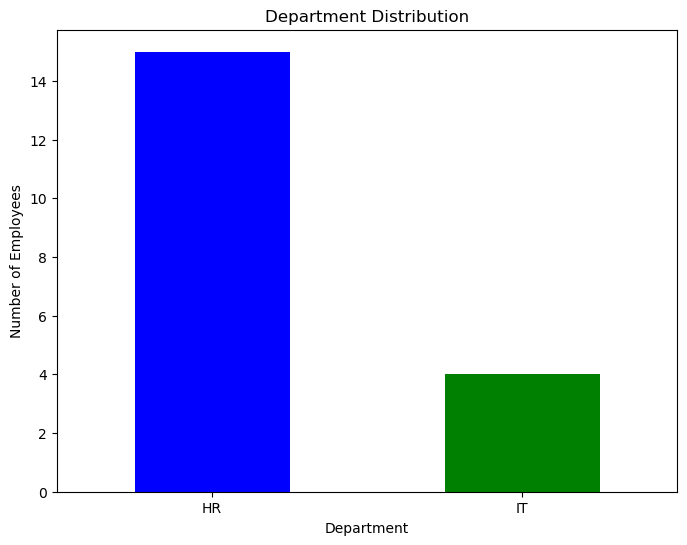

In [27]:
department_counts = data[['Department_hr', 'Department_it']].sum()

# Plotting department distribution
department_counts.plot(kind='bar', color=['blue', 'green'], figsize=(8, 6))
plt.title("Department Distribution")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.xticks([0, 1], labels=["HR", "IT"], rotation=0)
plt.show()

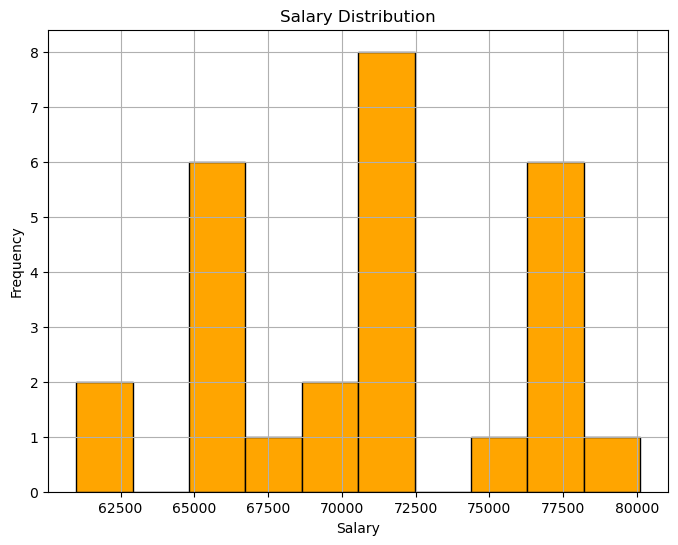

In [28]:
plt.figure(figsize=(8, 6))
plt.hist(data['Salary'], bins=10, color='orange', edgecolor='black')
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

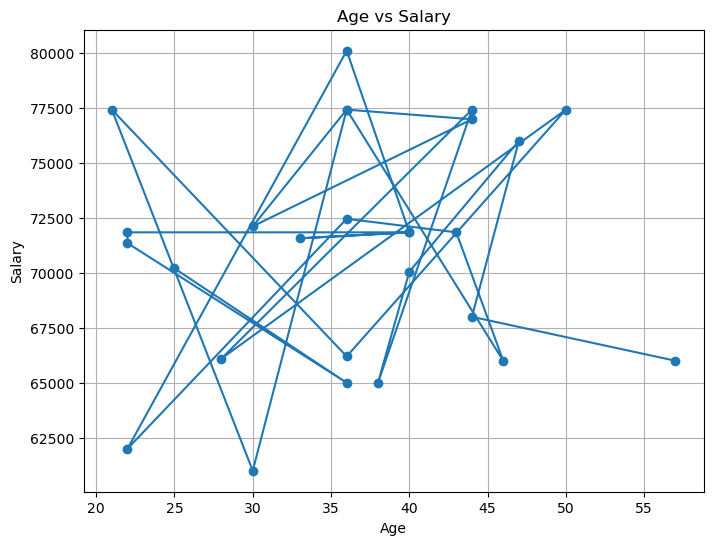

In [29]:
plt.figure(figsize=(8, 6))

plt.plot(data['Age'], data['Salary'], marker='o')

plt.title("Age vs Salary")
plt.xlabel("Age")
plt.ylabel("Salary")
plt.grid(True)

plt.show()

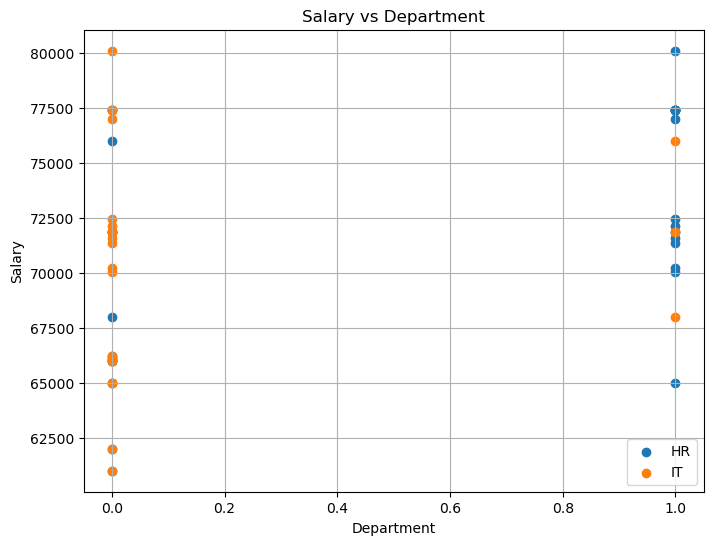

In [30]:
plt.figure(figsize=(8, 6))

plt.scatter(data['Department_hr'], data['Salary'], label='HR')
plt.scatter(data['Department_it'], data['Salary'], label='IT')

plt.title("Salary vs Department")
plt.xlabel("Department")
plt.ylabel("Salary")
plt.legend()
plt.grid(True)

plt.show()